# Detección de Anomalías: Isolation Forest y LOF

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/17_isolation_forest_y_lof.ipynb)

## Objetivos


- Contrastar dos filosofías dedicadas a la caza de anomalías en alta dimensionalidad: basada en distancias locales (LOF) vs. basada en aislamiento aleatorio (*Isolation Forest*).
- Comprender por qué *Isolation Forest* es el estándar industrial para Big Data debido a su complejidad lineal $O(N)$ y bajo consumo de memoria.
- **Criterio de Ingeniería:** Integrar el hiperparámetro `contamination` como una traducción directa del "apetito de riesgo" y la capacidad operativa del negocio.



## Prerrequisitos


- Entendimiento de la Detección de Anomalías como un problema no supervisado.
- Haber completado: [Detección de Anomalías por Error de Reconstrucción (PCA)](16_anomalias_por_reconstruccion_pca.ipynb).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

## Introducción Teórica



En el notebook anterior, construimos un detector de anomalías "artesanal" usando PCA. Funcionó bien, pero PCA asume que los datos normales viven en un subespacio lineal. Si los datos normales forman *clusters* complejos o densidades variables, PCA fallará.

Necesitamos algoritmos diseñados *específicamente* para encontrar la aguja en el pajar, sin importar la forma del pajar.

### 1. Local Outlier Factor (LOF) - El Enfoque de Densidad Local


LOF se basa en la misma filosofía que DBSCAN (densidad espacial) y KNN (distancias).
La idea es intuitiva: si un punto está rodeado de muchos vecinos muy cerca, está en una zona densa (Normal). Si un punto está muy lejos de sus vecinos más cercanos, está en una zona vacía (Anomalía).

LOF calcula la densidad local de un punto y la compara con la densidad local de sus vecinos. Si la densidad del punto es sustancialmente menor que la de sus vecinos, se marca como un *Outlier Local*.

**⚠️ El Problema de Ingeniería:**  
Para calcular esto, LOF debe medir la distancia de cada punto contra *todos* los demás puntos del dataset. Su complejidad temporal es $O(N^2)$. Si se tienen un millón de transacciones bancarias, LOF tardará horas o días en ejecutarse. Es excelente para datasets pequeños, pero inviable para Big Data.

### 2. Isolation Forest - El Enfoque de Aislamiento Aleatorio



*Isolation Forest* (Bosque de Aislamiento) revolucionó la detección de anomalías en 2008. En lugar de perfilar la "normalidad" (como PCA o LOF), **intenta aislar las anomalías directamente**.

Funciona construyendo árboles de decisión aleatorios:
1. Selecciona una característica al azar (ej. Monto de la transacción).
2. Selecciona un valor de corte al azar entre el mínimo y el máximo de esa característica.
3. Divide los datos.
4. Repite recursivamente hasta que cada punto quede aislado en su propia hoja.


Las anomalías, por definición, son "pocas y diferentes". Al hacer cortes aleatorios, las anomalías quedarán aisladas muy rápidamente (cerca de la raíz del árbol). Los puntos normales, al estar agrupados densamente, requerirán cientos de cortes para ser aislados (profundidad máxima).

El *Score* de anomalía es simplemente la **profundidad promedio** a la que un punto queda aislado en un bosque de 100 árboles. A menor profundidad, mayor probabilidad de ser una anomalía.

La siguiente figura intenta mostrar la comparativa entre ambos modelos, el punto rojo sería la anomalía:

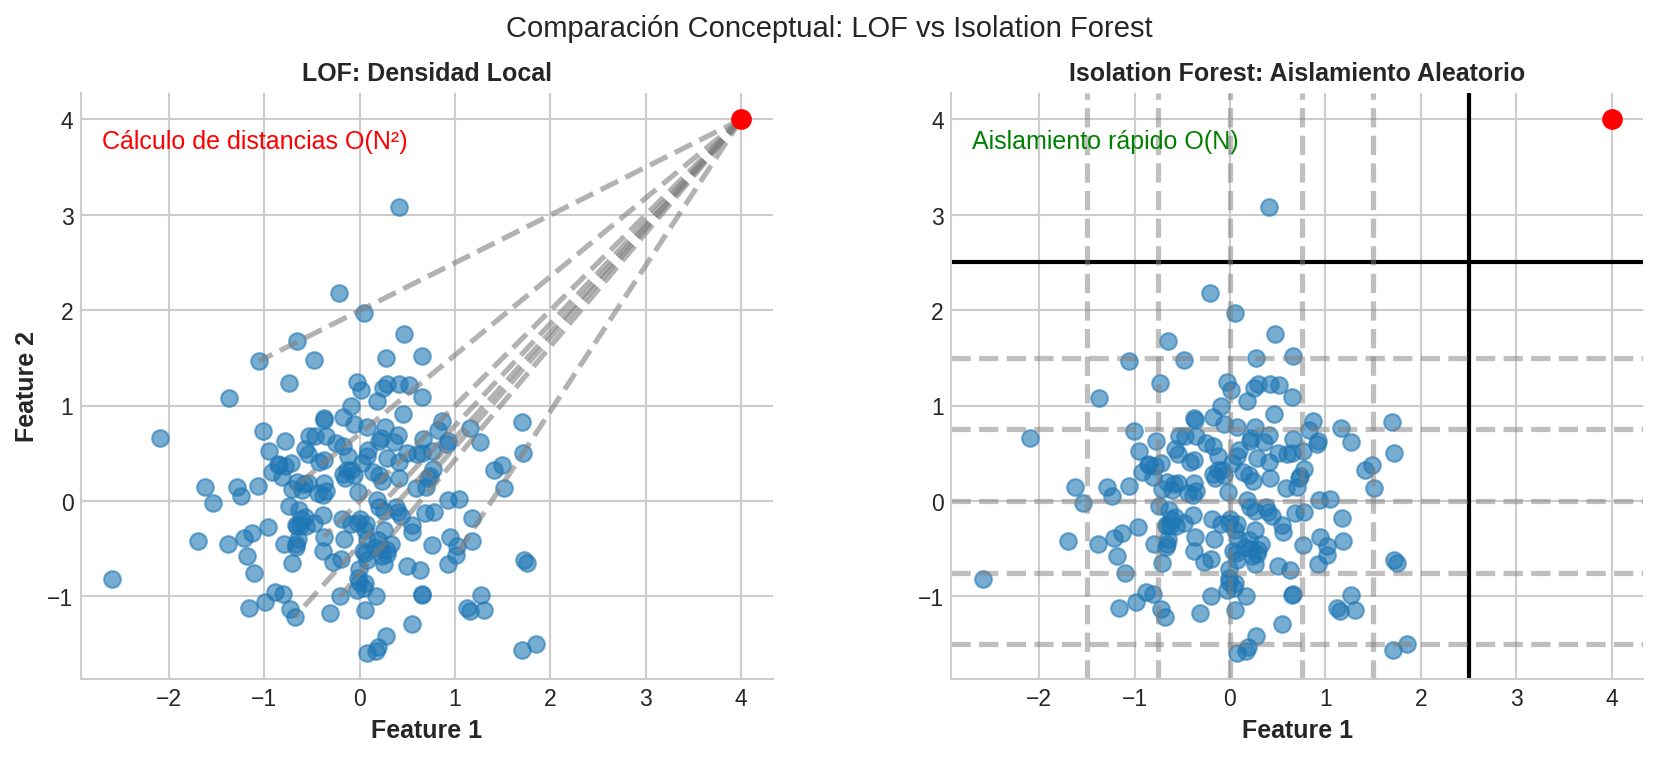

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#  Generar datos
np.random.seed(42)

# Nube densa (normal)
X = np.random.randn(200, 2) * 0.8

# Anomalía
anomaly = np.array([[4, 4]])


plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# IZQUIERDA: LOF
# -------------------------
ax = axes[0]

# Scatter
ax.scatter(X[:, 0], X[:, 1],
           color='#1f77b4',
           alpha=0.6)

ax.scatter(anomaly[:, 0], anomaly[:, 1],
           color='red',
           s=80,
           zorder=5)

# Dibujar líneas de distancia (simulación KNN)
for i in range(8):
    idx = np.random.randint(0, len(X))
    point = X[idx]

    ax.plot([anomaly[0, 0], point[0]],
            [anomaly[0, 1], point[1]],
            linestyle='--',
            color='gray',
            alpha=0.6)

ax.text(-2.7, 3.7, 'Cálculo de distancias O(N²)',
        fontsize=12,
        color='red')

ax.set_title('LOF: Densidad Local', fontsize=12)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')

# -------------------------
# DERECHA: ISOLATION FOREST
# -------------------------
ax = axes[1]

# Scatter
ax.scatter(X[:, 0], X[:, 1],
           color='#1f77b4',
           alpha=0.6)

ax.scatter(anomaly[:, 0], anomaly[:, 1],
           color='red',
           s=80,
           zorder=5)

# Cortes aleatorios (simulación árboles)
# Cortes que aíslan rápido la anomalía
cuts = [
    ('v', 2.5),
    ('h', 2.5),
]

for direction, val in cuts:
    if direction == 'v':
        ax.axvline(val, color='black', linewidth=2)
    else:
        ax.axhline(val, color='black', linewidth=2)

# Más cortes en zona densa
for val in np.linspace(-1.5, 1.5, 5):
    ax.axvline(val, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(val, color='gray', linestyle='--', alpha=0.5)

ax.text(-2.7, 3.7, 'Aislamiento rápido O(N)',
        fontsize=12,
        color='green')

ax.set_title('Isolation Forest: Aislamiento Aleatorio', fontsize=12)
ax.set_xlabel('Feature 1')


for ax in axes:
    ax.set_aspect('equal')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle('Comparación Conceptual: LOF vs Isolation Forest', fontsize=14)
plt.tight_layout()
plt.show()

## Desarrollo e Implementación


Vamos a retomar nuestro **Credit Card Fraud Dataset**. Esta vez, enfrentamos a LOF contra *Isolation Forest* y medimos sus tiempos de ejecución.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# 1. Carga de datos
dataset_path = "datasets/ccf/creditcard_sample.csv"
df = load_dataset(dataset_path)

# Nuevamente, camino full NO SUPERVISADO para los modelos.
# "Class" lo usamos simplemente para comparar resultados al final
X = df.drop(columns=['Class', 'Time'], errors='ignore')
y_true = df['Class']

# 2. Estandarización (Vital para LOF que usa distancias. Isolation Forest, al usar árboles, es inmune a la escala, pero lo aplicamos a todo por equidad)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Transacciones a procesar: {len(X_scaled)}")

Archivo CSV no encontrado. Descomprimiendo /content/applied-ai-engineering/datasets/ccf/creditcard_sample.zip...
Descompresión completa. Intentando cargar el CSV.
Dataset cargado exitosamente con 10000 filas y 31 columnas.
Transacciones a procesar: 10000


### El Parámetro `contamination` (Traduciendo Negocio a Código)



En el notebook anterior, calculamos el umbral del `Percentil 98` a mano. Scikit-Learn nos facilita la vida: ambos algoritmos aceptan el parámetro `contamination`.

Si el Director de Riesgos del banco nos dice: *"Tenemos presupuesto para investigar el 2% de las transacciones diarias"*, simplemente pasamos `contamination=0.02`. El algoritmo calculará los *scores* internamente y trazará el umbral automáticamente, devolviendo `-1` para las anomalías y `1` para los datos normales.

In [20]:
# Definimos el apetito de riesgo del negocio
contaminacion_negocio = 0.02

# --- 1. Local Outlier Factor (LOF) ---
start_time = time.time()
# n_neighbors=20 es el estándar. novelty=False (default) porque estamos detectando outliers en el dataset de entrenamiento.
lof = LocalOutlierFactor(n_neighbors=20, contamination=contaminacion_negocio, n_jobs=-1)
y_pred_lof = lof.fit_predict(X_scaled)
time_lof = time.time() - start_time

# --- 2. Isolation Forest ---
start_time = time.time()
# n_estimators=100 árboles. max_samples='auto' (256 muestras por árbol, lo que lo hace rapidísimo).
iforest = IsolationForest(n_estimators=100, contamination=contaminacion_negocio, random_state=42, n_jobs=-1)
y_pred_iforest = iforest.fit_predict(X_scaled)
time_iforest = time.time() - start_time

print(f"Tiempos de ejecución:")
print(f"LOF:             {time_lof:.4f} segundos")
print(f"Isolation Forest: {time_iforest:.4f} segundos")

Tiempos de ejecución:
LOF:             0.5038 segundos
Isolation Forest: 0.2862 segundos



*Nota de Ingeniería:* En este dataset reducido, la diferencia de tiempo puede no parecer mucho. Pero escalando esto a 1 millón de filas, LOF colapsará la memoria RAM, mientras que *Isolation Forest* terminará en menos de un minuto gracias a que solo usa submuestras de 256 datos por árbol (`max_samples='auto'`). Además de pasar a ser notorio el costo cuadrático.

### Evaluando el Rendimiento (Cazando Fraudes)



Vamos a convertir las predicciones de Scikit-Learn (`-1` para anomalía, `1` para normal) a nuestro formato estándar (`1` para fraude, `0` para normal) para poder evaluarlas contra las etiquetas reales.



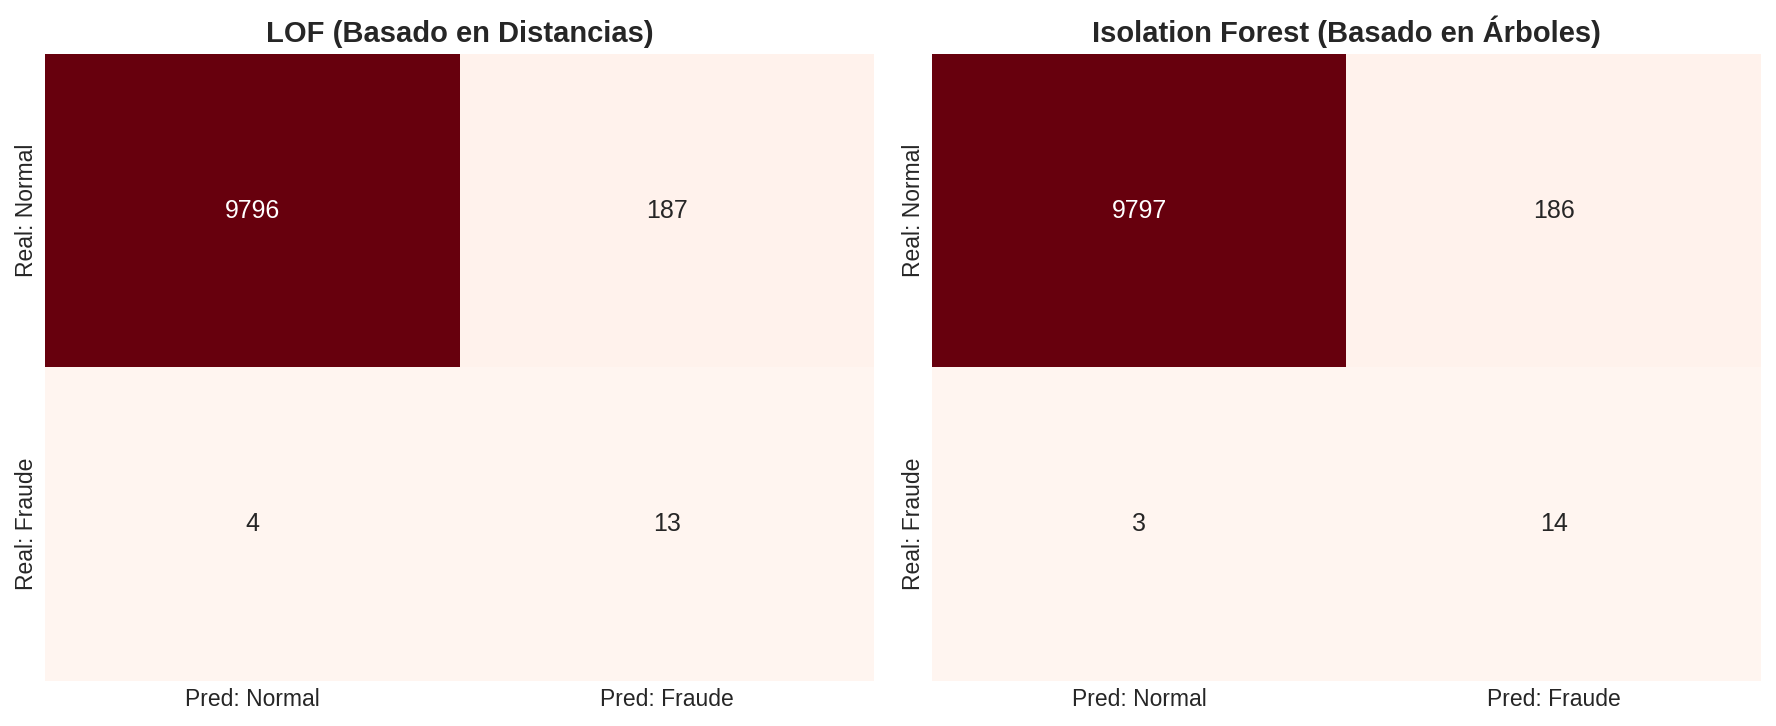

--- Reporte Isolation Forest ---
              precision    recall  f1-score   support

  Normal (0)       1.00      0.98      0.99      9983
  Fraude (1)       0.07      0.82      0.13        17

    accuracy                           0.98     10000
   macro avg       0.53      0.90      0.56     10000
weighted avg       1.00      0.98      0.99     10000



Class,Precision,Recall,F-score,Support
Normal (0),1.00,0.98,0.99,9983
Fraude (1),0.07,0.82,0.13,17
Avg.,1.00,0.98,0.99,10000


In [13]:
# Convertimos las etiquetas (-1, 1) a (1, 0)
y_pred_lof_bin = np.where(y_pred_lof == -1, 1, 0)
y_pred_iforest_bin = np.where(y_pred_iforest == -1, 1, 0)

# Función auxiliar para graficar matrices de confusión
def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False, ax=ax,
                xticklabels=['Pred: Normal', 'Pred: Fraude'],
                yticklabels=['Real: Normal', 'Real: Fraude'])
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_cm(y_true, y_pred_lof_bin, "LOF (Basado en Distancias)", axes[0])
plot_cm(y_true, y_pred_iforest_bin, "Isolation Forest (Basado en Árboles)", axes[1])
plt.tight_layout()
plt.show()

print("--- Reporte Isolation Forest ---")
print(classification_report(y_true, y_pred_iforest_bin, target_names=['Normal (0)', 'Fraude (1)']))

# O más estético con la función de las utilidades...
from utils.plots import render_classification_report
render_classification_report(y_true, y_pred_iforest_bin, classes=['Normal (0)', 'Fraude (1)'], show_support=True, caption="Reporte de Clasificación - Isolation Forest")

## Resultados y Discusión


Analizar las matrices de confusión. Recordar que **ninguno de estos modelos vio una etiqueta de fraude durante el entrenamiento**.

1. **LOF (Izquierda):** LOF atrapó 13 fraudes reales (Verdaderos Positivos, cuadrante inferior derecho). ¿Por qué? Porque en alta dimensionalidad (28 variables), las distancias euclidianas pierden significado (la Maldición de la Dimensionalidad). Todos los puntos parecen estar a la misma distancia, por lo que la "densidad local" se vuelve un concepto borroso. En este caso no se nota "mucho", pero tenerlo en cuenta.
2. **Isolation Forest (Derecha):** ¡Atrapó a 14, la gran mayoría de los fraudes! Al usar árboles de decisión aleatorios, *Isolation Forest* ignora las distancias geométricas. Simplemente corta el espacio. Los fraudes, al tener valores extremos en un par de variables clave, quedan aislados en los primeros 2 o 3 cortes del árbol. Obtuvo 186 falsos positivo, uno menos que LOF.

### La Flexibilidad de Producción (El Método `.decision_function()`)



En producción, no queremos reentrenar el modelo cada vez que el Director de Riesgos cambia de opinión sobre el presupuesto.

*Isolation Forest* nos permite extraer los *Scores* de anomalía crudos usando `.decision_function()`. (Valores negativos indican anomalía, valores positivos indican normalidad). Así, podemos ajustar el umbral dinámicamente sin tocar el modelo, o incluso, usar el modelo para entender los datos y tomar una decisión (cuando estamos trabajando totalmente a ciegas).



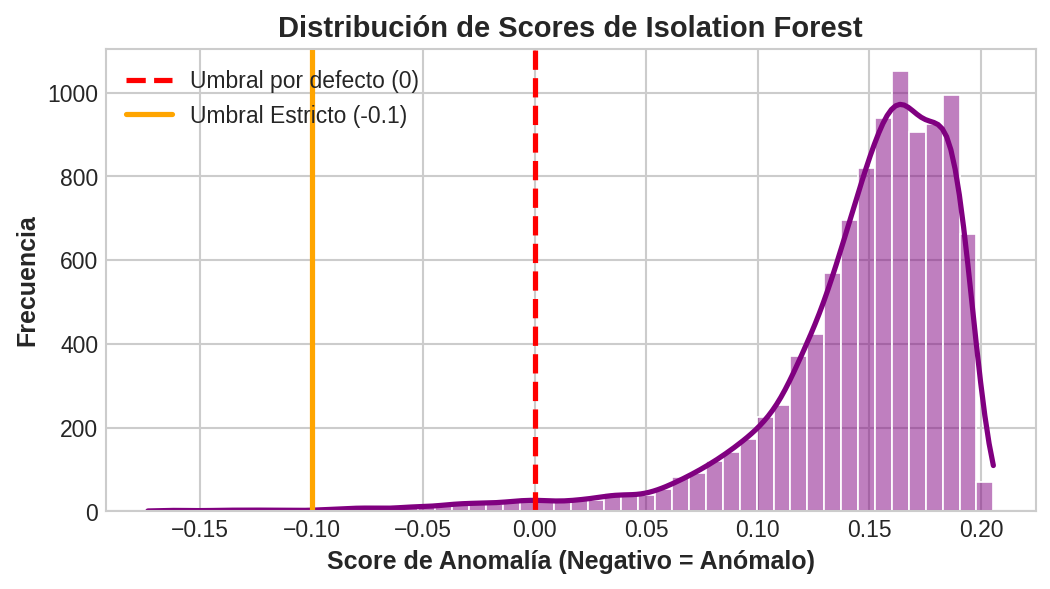

In [14]:
# Extraemos los scores crudos
scores_anomalia = iforest.decision_function(X_scaled)

plt.figure(figsize=(8, 4))
sns.histplot(scores_anomalia, bins=50, color='purple', kde=True)
plt.axvline(0, color='red', linestyle='--', label='Umbral por defecto (0)')

# Si el negocio quiere ser más estricto (atrapar menos falsos positivos), movemos el umbral a la izquierda
umbral_estricto = -0.10
plt.axvline(umbral_estricto, color='orange', linestyle='-', label=f'Umbral Estricto ({umbral_estricto})')

plt.title("Distribución de Scores de Isolation Forest")
plt.xlabel("Score de Anomalía (Negativo = Anómalo)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

Para usar lo mismo con LOF, debemos usar el modelo en `novelty=True`, notar que la gráfica de distribución o *score* de anomalía es diferente.

El umbral lo pongo a ojo acá (ejemplo solamente). Al usar `contamination`, se ordenan las muestras según el score y se obtiene el umbral a partir del porcentaje de muestras indicadas como anómalas (es exacto lo que estaba explicado arriba).

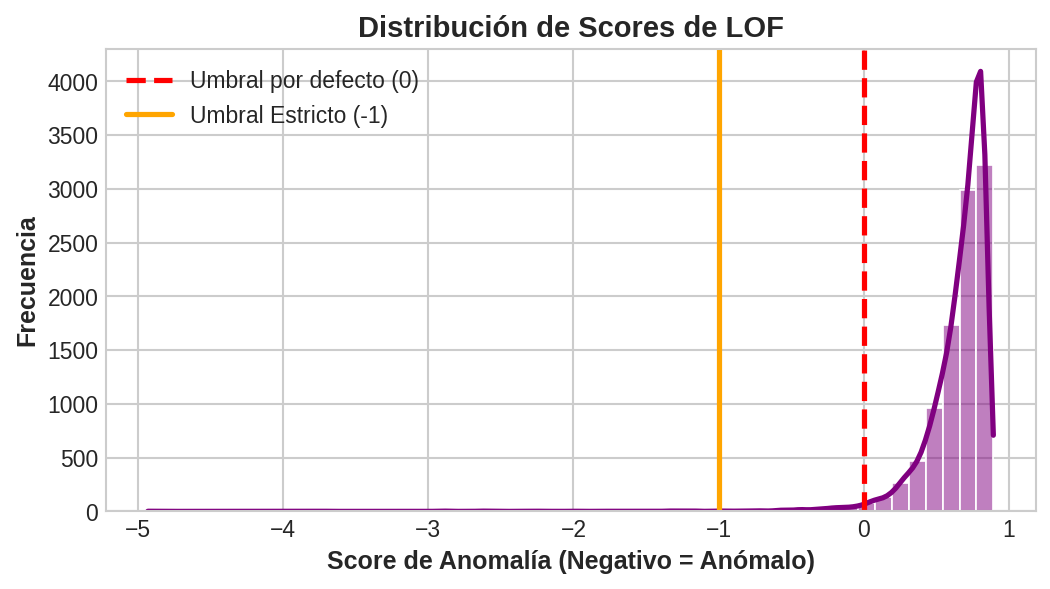

In [24]:
# Establecemos el modelo en modo de predicciones
lof.novelty = True

# Extraemos los scores crudos
scores_anomalia_lof = lof.decision_function(X_scaled)

plt.figure(figsize=(8, 4))
sns.histplot(scores_anomalia_lof, bins=50, color='purple', kde=True)
plt.axvline(0, color='red', linestyle='--', label='Umbral por defecto (0)')

umbral_estricto = -1
plt.axvline(umbral_estricto, color='orange', linestyle='-', label=f'Umbral Estricto ({umbral_estricto})')

plt.title("Distribución de Scores de LOF")
plt.xlabel("Score de Anomalía (Negativo = Anómalo)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

Aclaración importante desde la documentación de `scikit-learn` (traducción):

> Cuando `novelty` está configurada como verdadera, tenga en cuenta que solo debe usar `predict`, `decision_function` y `score_samples` en datos nuevos no vistos, y no en las muestras de entrenamiento, ya que esto generaría resultados erróneos. Es decir, el resultado de `predict` no será el mismo que el de `fit_predict`. Las puntuaciones de anormalidad de las muestras de entrenamiento siempre están disponibles a través del atributo `negative_outlier_factor_`.

*Así que, la gráfica de arriba es meramente ilustrativa...*

## Conexiones y Próximos Pasos



Con esto, cubrimos el uso de herramientas para la Detección de Anomalías en datos tabulares, incluso masivos. *Isolation Forest* es rápido, no requiere escalado y maneja la alta dimensionalidad con elegancia.

Pero, ¿qué pasa si nuestro problema no es encontrar anomalías, sino clasificar datos normales, y tenemos 1 millón de muestras pero solo presupuesto para etiquetar a mano 1.000 de ellas (o menos inclusivo)?

- ➡️ **Siguiente:** En el notebook [Aprendizaje Semi-Supervisado](18_aprendizaje_semi_supervisado.ipynb), llegamos al clímax del capítulo. Aprendemos a combinar la potencia predictiva de los modelos supervisados (SVC) con la intuición topológica de los modelos no supervisados (Grafos) para resolver el problema más común de la industria: la escasez de etiquetas.
- 🔄 **Relacionado:** Si se quiere entender por qué *Isolation Forest* es tan rápido al usar submuestras aleatorias, repasar el concepto de *Bagging* en el notebook [Ensamblado de Modelos](08_ensamblado_de_modelos.ipynb). Además, ahora hay mejor contexto para entender el modelo IF presentado en el capítulo de EDA, y "configurarlo" adecuadamente [Detección Avanzada de Anomalías y Ruido](../02_eda/07_deteccion_avanzada_anomalias.ipynb).

## Referencias


1. Liu, F. T., Ting, K. M., & Zhou, Z. H. (2008). *Isolation forest*. In 2008 eighth ieee international conference on data mining (pp. 413-422). IEEE.
2. Breunig, M. M., Kriegel, H. P., Ng, R. T., & Sander, J. (2000). *LOF: identifying density-based local outliers*. In Proceedings of the 2000 ACM SIGMOD international conference on Management of data (pp. 93-104).
3. [Scikit-Learn: Novelty and Outlier Detection](https://scikit-learn.org/stable/modules/outlier_detection.html)


Hay otros algoritmos, recomendado ver:

4. [*Comparing anomaly detection algorithms for outlier detection on toy datasets*](https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_anomaly_comparison.html)

---


## Entorno de Ejecución


In [15]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
